# Will the car hit an obstacle? Collision verification with PyBDR

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ASAG-ISCAS/PyBDR/blob/master/examples/colab_demo.ipynb)

A car drives in the right lane of a road. A **parked car** blocks the lane ahead, so the controller
steers the car into the left lane. A **traffic cone** stands on the left shoulder. The position and the
heading of the car are only known up to an uncertain, **non-convex** set. Does the car hit one of the
obstacles, for *every* possible initial state?

Simulating a few initial states cannot answer this, since the uncertain set contains infinitely many.
PyBDR computes **reachable sets**, which enclose all trajectories:

1. the boundary of the non-convex initial set is covered by small boxes with interval analysis (codac),
2. the reachable sets of these boxes are computed with the set-boundary based method,
3. an obstacle that no reachable set touches is **verified** to be collision-free; an obstacle touched by
   a reachable set *may* be hit, which simulations then confirm.

In [1]:
# install PyBDR when running on Colab (skipped when it is already installed)
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pybdr") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pybdr[vis] @ git+https://github.com/ASAG-ISCAS/PyBDR"])

In [2]:
%matplotlib inline
import time

import codac
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from scipy.integrate import solve_ivp
from scipy.optimize import linprog
from sympy import Matrix, cos, lambdify, sin, symbols

import pybdr
from pybdr.algorithm import ASB2008CDC
from pybdr.geometry import Geometry, Interval, Zonotope
from pybdr.geometry.operation import cvt2
from pybdr.util.functional import function_boundary
from pybdr.util.visualization import plot, plot3d, plot_tube

print("PyBDR", pybdr.__version__)

PyBDR 1.1.0


## 1. The car and its controller

The car is a Dubins car: it drives with constant speed $v$ in the direction of its heading $\theta$,
and the controller sets the turning rate. To move to the left lane (centered at $y = 1$, the right lane
is centered at $y = 0$) it steers proportionally to the lateral offset and the heading:

$$
\dot x = v \cos\theta, \qquad \dot y = v \sin\theta, \qquad
\dot\theta = -k_y\,(y - 1) - k_\theta\,\theta .
$$

$(x, y)$ is the reference point of the car; the obstacles below are enlarged by the size of the car,
so a collision means that the reference point enters an obstacle.

In [3]:
V, K_Y, K_THETA, LEFT_LANE = 1.0, 0.9, 1.3, 1.0


def lane_change(x, u):
    # x = (x, y, theta), u: unused input, dynamics as sympy expressions
    return Matrix([V * cos(x[2]), V * sin(x[2]), -K_Y * (x[1] - LEFT_LANE) - K_THETA * x[2] + u[0]])

## 2. A non-convex initial set

The position of the car is known to lie in a peanut shaped region (a Cassini oval, e.g. two localization
hypotheses along the lane), the heading is in $[-0.1, 0.1]$ rad. The initial set is
$\{(x, y, \theta) \mid F(x, y, \theta) \le 0\}$ with

$$
F = \max\bigl(f(x, y),\ \theta^2 - 0.1^2\bigr), \qquad
f = (X^2 + Y^2)^2 - 2c^2 (X^2 - Y^2) - (a^4 - c^4), \quad X = \tfrac{x}{0.25},\ Y = \tfrac{y}{0.12} .
$$

codac covers the boundary $\{F = 0\}$ with boxes of width at most 0.1. Only these boxes are propagated
in the next step: the reachable set of the interior is enclosed by the reachable set of the boundary.

In [4]:
x = codac.VectorVar(3)
X, Y, c, a = x[0] / 0.25, x[1] / 0.12, 1.0, 1.08
f = codac.sqr(codac.sqr(X) + codac.sqr(Y)) - 2 * c**2 * (codac.sqr(X) - codac.sqr(Y)) - (a**4 - c**4)
F = codac.AnalyticFunction([x], codac.max(f, codac.sqr(x[2]) - 0.1**2))


def in_initial_set(state):
    return F.eval(codac.Vector(list(state))).ub() <= 0


start = time.perf_counter()
cells = function_boundary(F, Interval([-1, -0.5, -0.5], [1, 0.5, 0.5]), eps=0.1)
print(f"{len(cells)} boundary boxes in {time.perf_counter() - start:.2f}s")

108 boundary boxes in 0.01s


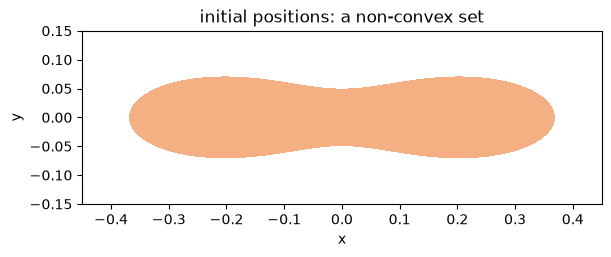

In [5]:
# the possible initial positions of the car
xs, ys = np.meshgrid(np.linspace(-0.45, 0.45, 400), np.linspace(-0.15, 0.15, 200))
Xs, Ys = xs / 0.25, ys / 0.12
fig, ax = plt.subplots(figsize=(6, 2.6), layout="constrained")
ax.contourf(xs, ys, (Xs**2 + Ys**2) ** 2 - 2 * (Xs**2 - Ys**2) - (1.08**4 - 1), levels=[-10, 0], colors=["#F4B083"])
ax.set(aspect="equal", xlabel="x", ylabel="y", title="initial positions: a non-convex set")
plt.show()

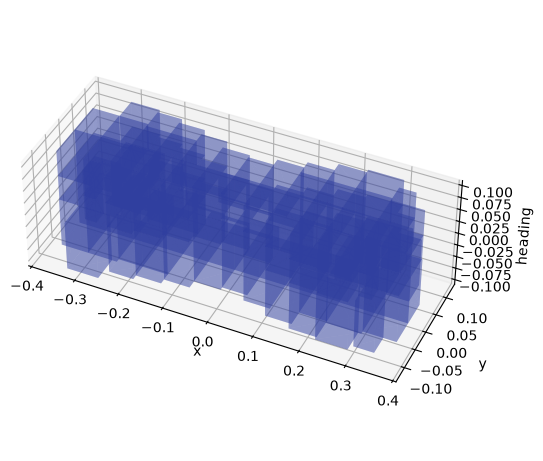

In [6]:
# the boxes covering the boundary of the initial set in (x, y, theta): the side of the peanut shaped
# prism and its top and bottom (theta = +-0.1)
fig, ax = plot3d(cells, [0, 1, 2], backend="matplotlib", color="#303F9F", opacity=0.3, width=700, height=450, show=False)
ax.set_box_aspect((0.9, 0.35, 0.3))   # true proportions of the set
ax.view_init(elev=40, azim=-65)
ax.set(xlabel="x", ylabel="y", zlabel="heading")
plt.show()

## 3. The scene

In [7]:
OBSTACLES = {
    "parked car": (Interval([1.2, -0.5], [2.2, 0.3]), "#E53935"),
    "traffic cone": (Interval([4.0, 1.2], [4.6, 1.5]), "#43A047"),
}


def draw_scene(ax):
    for y in (-0.5, 1.5):
        ax.axhline(y, color="k", lw=1.5)          # road edges
    ax.axhline(0.5, color="k", lw=1, ls="--")     # lane marking
    for name, (box, color) in OBSTACLES.items():
        ax.add_patch(Rectangle(box.inf, *(box.sup - box.inf), facecolor=color, alpha=0.35, edgecolor=color))
        ax.annotate(name, box.sup, xytext=(4, 4), textcoords="offset points", color=color)
    ax.set(xlim=(-0.8, 6.5), ylim=(-0.8, 1.9), xlabel="x", ylabel="y")
    ax.set_aspect("equal", adjustable="box")

## 4. Reachable sets

The reachable sets of all boundary boxes are computed in parallel over 6 seconds.

In [8]:
options = ASB2008CDC.Options()
options.t_end = 6.0
options.step = 0.05
options.tensor_order = 2
options.taylor_terms = 4
options.u = Zonotope.zero(1, 1)
options.u_trans = np.zeros(1)
Zonotope.REDUCE_METHOD = Zonotope.REDUCE_METHOD.GIRARD
Zonotope.ORDER = 50

start = time.perf_counter()
ri, rp = ASB2008CDC.reach_parallel(lane_change, [3, 1], options, [cvt2(box, Geometry.TYPE.ZONOTOPE) for box in cells])
print(f"{len(ri) - 1} time steps x {len(cells)} boxes in {time.perf_counter() - start:.0f}s")

120 time steps x 108 boxes in 20s


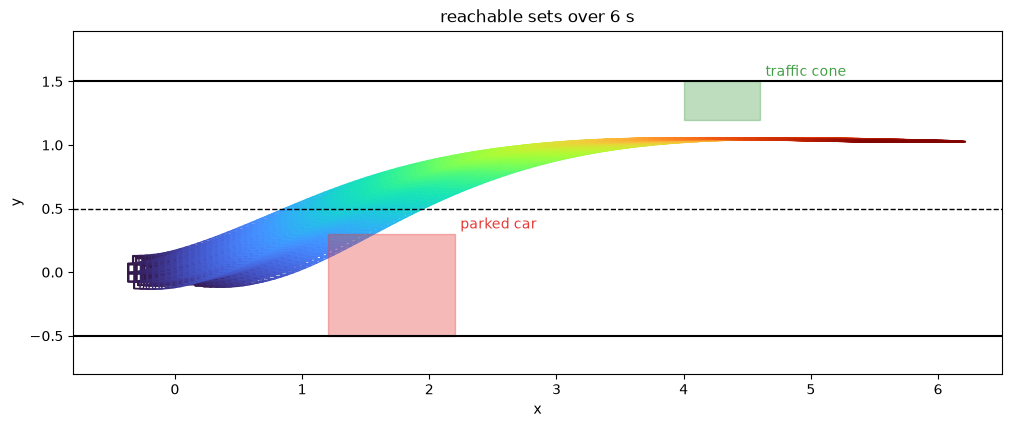

In [9]:
fig, ax = plot(ri, [0, 1], width=1000, height=420, show=False)   # colored by time, blue to red
draw_scene(ax)
ax.set_title("reachable sets over 6 s")
plt.show()

## 5. Verification

`ri[k]` holds the reachable sets of the time interval $[t_{k-1}, t_k]$. A zonotope $\{c + G\beta \mid
\beta \in [-1, 1]^m\}$ intersects a box $[l, u]$ exactly if the linear program
$l \le c + G\beta \le u,\ -1 \le \beta \le 1$ is feasible (only the $(x, y)$ part matters).

In [10]:
def intersects(z, box):
    c, g = z.c[:2], z.gen[:2]
    res = linprog(np.zeros(g.shape[1]), A_ub=np.vstack([g, -g]), b_ub=np.concatenate([box.sup - c, c - box.inf]),
                  bounds=[(-1, 1)] * g.shape[1], method="highs")
    return res.status == 0


for name, (box, _) in OBSTACLES.items():
    steps = [k for k in range(1, len(ri)) if any(intersects(z, box) for z in ri[k])]
    if steps:
        print(f"{name:12s}: POSSIBLE COLLISION between t = {(steps[0] - 1) * options.step:.2f} s "
              f"and t = {steps[-1] * options.step:.2f} s")
    else:
        print(f"{name:12s}: verified collision-free for every initial state")

parked car  : POSSIBLE COLLISION between t = 0.85 s and t = 1.35 s


traffic cone: verified collision-free for every initial state


## 6. Checking with simulations

The reachable sets say that the parked car *may* be hit. Simulating random initial states from the
non-convex set shows that some of them really do hit it (red), while no trajectory comes close to the
cone. The simulations can only show that a collision happens, the reachable sets prove that one does
not.

parked car  : 50 of 200 trajectories hit it
traffic cone: 0 of 200 trajectories hit it


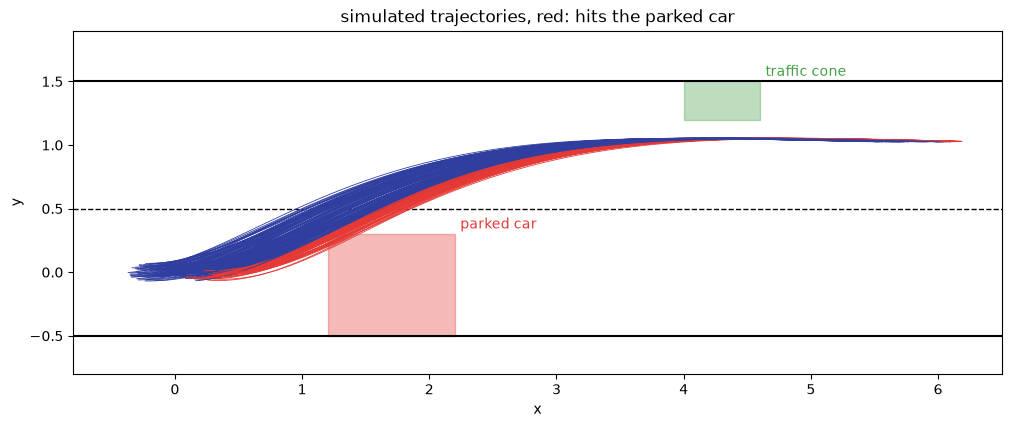

In [11]:
# numpy version of the same dynamics for the ODE solver
state_symbols, input_symbols = symbols("x:3"), symbols("u:1")
f_numpy = lambdify([state_symbols, input_symbols], lane_change(state_symbols, input_symbols), "numpy")


def rhs(_, state):
    return np.ravel(f_numpy(state, [0.0]))


rng = np.random.default_rng(0)
samples = []
while len(samples) < 200:
    state = rng.uniform([-0.45, -0.15, -0.1], [0.45, 0.15, 0.1])
    if in_initial_set(state):
        samples.append(state)

times = np.linspace(0, options.t_end, 241)
trajectories = [solve_ivp(rhs, (0, options.t_end), s, t_eval=times, rtol=1e-8).y for s in samples]


def hits(traj, box):
    return np.any(np.all((traj[:2].T >= box.inf) & (traj[:2].T <= box.sup), axis=1))


for name, (box, _) in OBSTACLES.items():
    print(f"{name:12s}: {sum(hits(tr, box) for tr in trajectories)} of {len(trajectories)} trajectories hit it")

fig, ax = plt.subplots(figsize=(10, 4.2), layout="constrained")
draw_scene(ax)
for tr in trajectories:
    ax.plot(tr[0], tr[1], lw=0.6, color="#E53935" if hits(tr, OBSTACLES["parked car"][0]) else "#303F9F")
ax.set_title("simulated trajectories, red: hits the parked car")
plt.show()

## 7. Over time

The reachable sets with time as third axis.

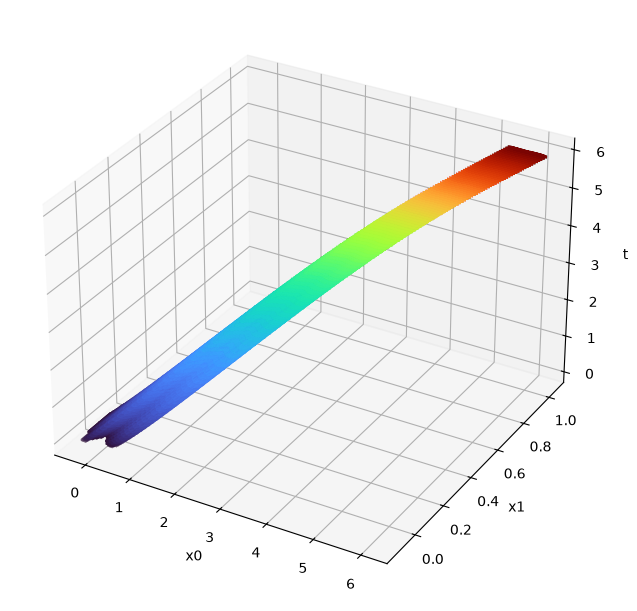

In [12]:
plot_tube(ri[1:], [0, 1], step=options.step, backend="matplotlib", width=800, height=600);

An interactive version to rotate and zoom (it only shows when the notebook runs). To keep it light,
each time step is drawn as the convex hull of the reachable sets of all boxes, a slight
over-approximation of the figure above.

In [13]:
hull_per_step = [cvt2(np.vstack([z.proj([0, 1]).polygon() for z in sets]), Geometry.TYPE.POLYTOPE) for sets in ri[1:]]
plot_tube(hull_per_step, [0, 1], step=options.step, width=800, height=600);

## Next

- [examples/](https://github.com/ASAG-ISCAS/PyBDR/tree/master/examples) has a notebook for every
  reachability algorithm of PyBDR.
- Try it: move the parked car further ahead (`OBSTACLES`), or make the controller more aggressive
  (`K_Y`), and verify again.